In this Notebook, we want to create empirical Derrida plots. These are plots that relate the current normalised Hamming distance between two initial configurations (horizontal axis) to the normalised Hamming distance of those configurations in the next time step (vertical axis). If the resulting data point in the scatter plot is above the first diagonal, the Hamming distance is increasing (the damage is spreading). Otherwise, the damage remains the same, or even shrinks. Especially interesting is the behaviour around the origin, which is a measure for the sensitivity to initial conditions. The slope of the linear fit through the first couple of points close to the origin is called the Derrida coefficient.

In this notebook we will
1. [CHECK] Define a function that creates two pairs of arrays that can be used to plot the Derrida plot
2. Define a function that can use these arrays to output a single Derrida coefficient
3. Define a function that can output the equivalent rule for isomorphically defined LLNAs, and use this function to create a subset of non-equivalent rules.
4. For all non-equivalent rules of a particular resolution, and for a particular network, create a plot that relates the Derrida coefficient with genotype parameters (Hamming weight and Boolean sensitivity). Note that we should only run over non-equivalent rules.
    - The hope is that the Boolean sensitivity will correlate with the Derrida coefficient.
5. For a number of particularly interesting rules, consider the influence of a network parameter on the Derrida coefficient.
    - We expect to see a sort of phase change when a particular average neighbourhood size is reached.

Remaining questions and further research topics are listed below:
- Can we make an analytical approximation of the Derrida plot and/or coordinate?
- What is the relationship with the Jacobian and other established methods?
- How does the Derrida coefficient relate to the mu sensitivity (which is not the same as the Boolean sensitivity after all)
- I should add the possiblity of choosing the order of the nodes that are being affected by the defect! In that way, I can compare what happens to the overall behaviour if you change states in nodes with high PageRank (for example) first, compared to low PageRank first. Right now, random nodes are being chosen every time.
- Perhaps I could make a Derrida plot counterpart for networks, where I look at the evolution of the size of the affected subgraph (?)
- Instead of the slope of the linear fit, I could look at the angle (0 to 90) and normalise it to 0 to 1. Not sure how useful that would be, though.

# 1. Function that creates the Derrida arrays

In [1]:
# standard preamble for the Notebooks I use

import torch as tc
import igraph as ig
import numpy as np
from numpy.typing import NDArray
from matplotlib import pyplot as plt
from matplotlib import rcParams
import math

from typing import Optional, Tuple, Union

# Enable LaTeX and set Times New Roman as the font
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: Use LaTeX packages
})

from tqdm import tqdm

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.automata import LLNA
from src.simulation import *

%load_ext autoreload
%autoreload 2

In [26]:
def get_derrida_arrays(graph:ig.Graph, model:LLNA, points_per_rho:int=1, init_config:Optional[NDArray]=None) -> Tuple[NDArray, NDArray]:
    """
    Function that generates the arrays that are required for creating a Derrida plot. It effectively selects `points_per_rho` randomly chosen defects per normalised Hamming distance.
    TODO: add a parameter to choose the number of random initial conditions
    TODO: add the possiblity of adding an array of multiple initial configurations
    TODO: add possiblity of choosing the order in which the nodes should be affected

    Parameters
    ----------
    graph : igraph.Graph
        Network (graph) used as the topology for the automaton. Will be interpreted as an undirected graph.
    model : src.automata.LLNA
        Life-like network automaton (custom class). Envelops the rules that govern the automaton.
    points_per_rho : int
        The desired number of data points per normalised Hamming weights in the input. If None the number will default to 1.
    init_config : numpy.ndarray, optional
        The desired initial configuration. If None, a random initial configuration is generated from a uniform distribution.

    Returns
    -------
    input_defect_density : numpy.ndarray
        Array containing the densities of the defects, i.e. the normalised Hamming distance, of the two original initial configurations.
    output_defect_density : numpy.ndarray
        Array containing the densities of the defects of the two configurations in the next time step.
    """
    # find the number of nodes in the network
    N = graph.vcount()

    # generate or verify the initial configuration
    if init_config is not None:
        if len(init_config) != N:
            raise Exception(f"The provided initial configuration should have length {N}.")
    else:
        init_config = np.random.randint(0,2,size=N)

    # get a long array of unique defects
    if points_per_rho > N:
        raise Exception(f"The number of data points per normalised hamming weight cannot be larger than or equal to {N}, because there are not that many unique combinations of defect arrays.")
    # create defect array using a help function
    defects_all = np.array([random_ones_arrays(N, points_per_rho, ones_per_array) for ones_per_array in range(1,N)])
    # put it in the right shape
    defects_all = defects_all.reshape((N-1)*points_per_rho, N)

    # calculate the effect of this defect on the initial configuration
    init_config_all = np.tile(init_config, ((N-1)*points_per_rho,1))
    init_config_defect_all = (init_config_all + defects_all) % 2

    # get ID of edges (bidirectional)
    graph.to_directed()
    edges = tc.tensor(graph.get_edgelist()).T
    graph.to_undirected()

    # run the model for a single time step
    next_config = np.array(model.step(edges, tc.tensor(init_config[np.newaxis,:])), dtype=int)[0]
    next_config_all = np.tile(next_config, ((N-1)*points_per_rho,1))
    next_config_defect_all = np.array(model.step(edges, tc.tensor(init_config_defect_all)), dtype=int)

    # find the normalised Hamming distance between both new configurations
    input_defect_density  = np.mean(defects_all, axis=1)
    output_defect_density = np.mean((next_config_all + next_config_defect_all) % 2, axis=1)

    return input_defect_density, output_defect_density

In [28]:
def random_ones_arrays(size: int, num_arrays: int, ones_per_array: int) -> NDArray:
    """
    Generates N arrays of given size, each containing a specified number of ones 
    at unique positions per row, ensuring rows are not identical.
    NOTE: made with ChatGPT

    Parameters
    ----------
    size : int
        The size of each array.
    num_arrays : int
        The number of arrays to generate.
    ones_per_array : int
        The number of ones per array.

    Returns
    -------
    numpy.ndarray
        A NumPy array of shape (num_arrays, size) where each row has exactly `ones_per_array` ones
        at unique positions per row, ensuring rows are unique.
    """
    if ones_per_array > size:
        raise ValueError("ones_per_array cannot exceed the array size (not enough space).")
    if num_arrays > math.comb(size, ones_per_array):
        raise ValueError("Not enough unique combinations of ones available.")

    arr = np.zeros((num_arrays, size), dtype=int)  # Initialize all zeros
    unique_rows = set()

    for i in range(num_arrays):
        while True:
            indices = tuple(sorted(np.random.choice(size, ones_per_array, replace=False)))  # Unique positions as a tuple
            if indices not in unique_rows:
                unique_rows.add(indices)
                break  # Found a unique row

        arr[i, list(indices)] = 1  # Set ones at selected positions

    return arr

(<Figure size 1000x180 with 1 Axes>,
 <Axes: title={'center': 'Diagram for LLNA $R_{3}B_{2}S_{5}$'}, xlabel="State density $\\rho$ of the node's neighbourhood", ylabel='Node becomes ...'>)

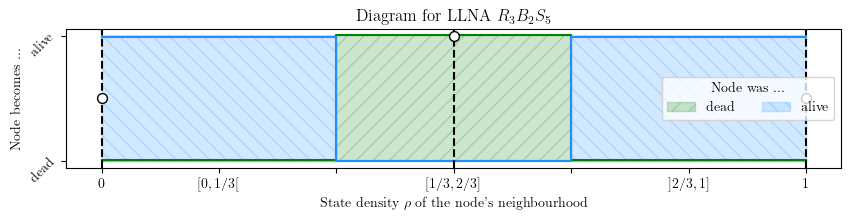

In [80]:
# Let's consider the Hamming weight and the Boolean sensitivity over two very different networks
num_nodes = 1000  # Number of nodes
num_edges_per_new_node = 3  # Number of edges each new node adds

# Generate Scale-Free Network (Barabási–Albert Model)
# ba_graph = ig.Graph.Barabasi(n=num_nodes, m=num_edges_per_new_node, directed=False)
ring_graph = ig.Graph.Ring(num_nodes)

resolution = 3
born_if = [1]
survive_if = [0,2]
model = LLNA(resolution, x=born_if, y=survive_if, iso=True)
# model = LLNA(resolution, iso=True)

model.diagram(degree=2, plot_dist=True)

100%|██████████| 1/1 [00:02<00:00,  2.39s/it]


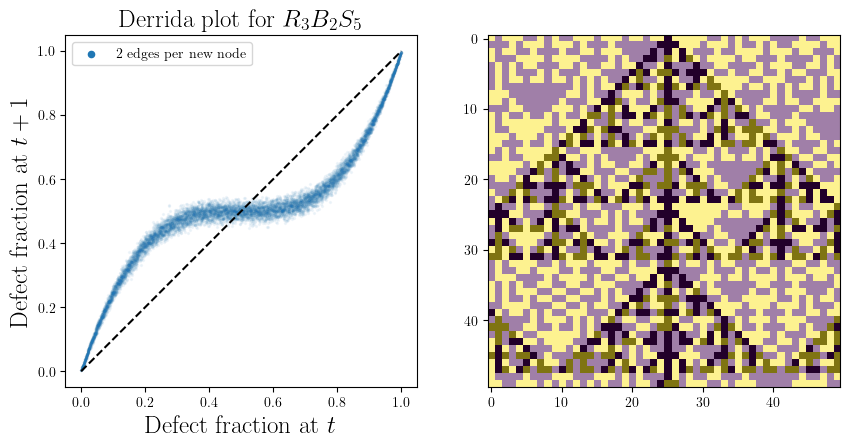

In [81]:
points_per_rho = 10
# init_config = np.zeros(num_nodes)
init_config = np.random.randint(0, 2, size=num_nodes)

num_nodes = 1000  # Number of nodes
num_edges_per_new_node_list = [2] #, 4, 6, 8, 10]  # Number of edges each new node adds

inputs_list = []
outputs_list = []
for num_edges_per_new_node in tqdm(num_edges_per_new_node_list, total=len(num_edges_per_new_node_list)):
    # Generate Scale-Free Network (Barabási–Albert Model)
    # ba_graph = ig.Graph.Barabasi(n=num_nodes, m=num_edges_per_new_node, directed=False)
    ring_graph = ig.Graph.Ring(num_nodes)
    inputs, outputs = get_derrida_arrays(ring_graph, model, points_per_rho=points_per_rho, init_config=init_config)
    inputs_list.append(inputs)
    outputs_list.append(outputs)

# find TEP for comparison
ring_graph.to_directed()
edges = tc.tensor(ring_graph.get_edgelist()).T
ring_graph.to_undirected()
H = np.array(model.forward(edges, tc.tensor(init_config[np.newaxis,:]), T=num_nodes-1), dtype=int)

edge_def_idx = 25
init_config_def = init_config.copy()
init_config_def[edge_def_idx] = 1-init_config_def[edge_def_idx]
H_def = np.array(model.forward(edges, tc.tensor(init_config_def[np.newaxis,:]), T=num_nodes-1), dtype=int)

# figure
fig, axs = plt.subplots(1,2,figsize=(10,5))
fontsize=18
alpha=0.05
axs[0].plot([0, 1], [0, 1], 'k--')
for inputs, outputs, num_edges_per_new_node in zip(inputs_list, outputs_list, num_edges_per_new_node_list):
    axs[0].scatter(inputs, outputs, alpha=alpha, s=2, label=fr"{num_edges_per_new_node} edges per new node")

axs[0].set_title(fr"Derrida plot for {model.__str__(latex=True)}", fontsize=fontsize)
axs[0].set_xlabel(fr"Defect fraction at $t$", fontsize=fontsize)
axs[0].set_ylabel(fr"Defect fraction at $t+1$", fontsize=fontsize)

legend = axs[0].legend()
for handle in legend.legend_handles:
    handle.set_alpha(1)  # Set marker transparency in legend
    handle.set_sizes([20])  # Change marker size in legend

axs[0].set_aspect(1)
axs[0].set_xlim([-0.05, 1.05])
axs[0].set_ylim([-0.05, 1.05])

# show cropped version of TEP
axs[1].imshow(H[0, :edge_def_idx*2, :edge_def_idx*2])
axs[1].imshow((H[0, :edge_def_idx*2, :edge_def_idx*2] + H_def[0, :edge_def_idx*2, :edge_def_idx*2]) % 2, cmap='Greys', alpha=0.5)
